Dataset Preview:
        Date Store   Item  Sales
0 2023-01-01     A  Shirt    100
1 2023-01-01     B  Pants    150
2 2023-01-02     A  Shirt    120
3 2023-01-02     B  Pants    180
4 2023-01-03     A  Shoes    200

Missing Values:
Date     0
Store    0
Item     0
Sales    0
dtype: int64

Descriptive Statistics:
Total Sales: 860
Average Sales: 143.33333333333334
Maximum Sales: 200
Minimum Sales: 100


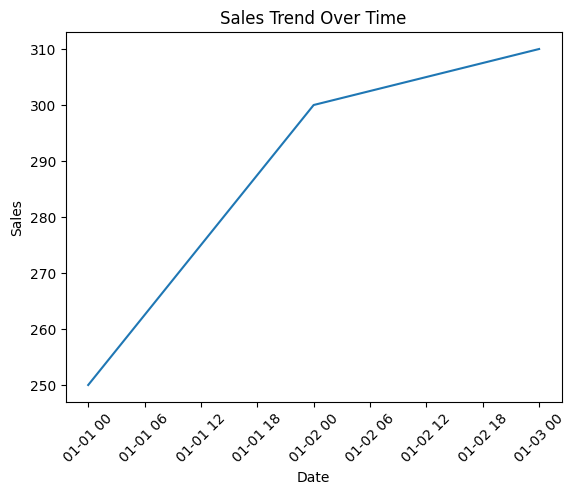

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


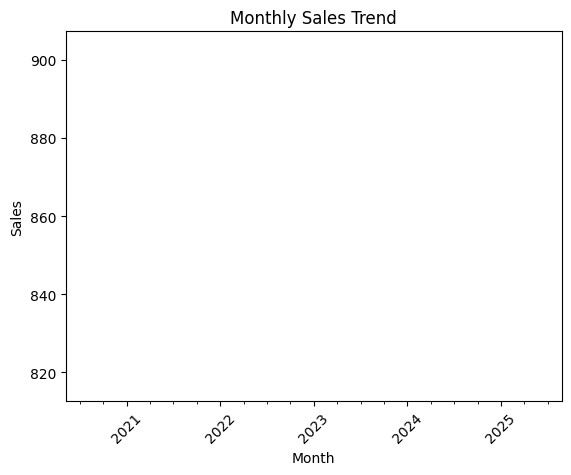

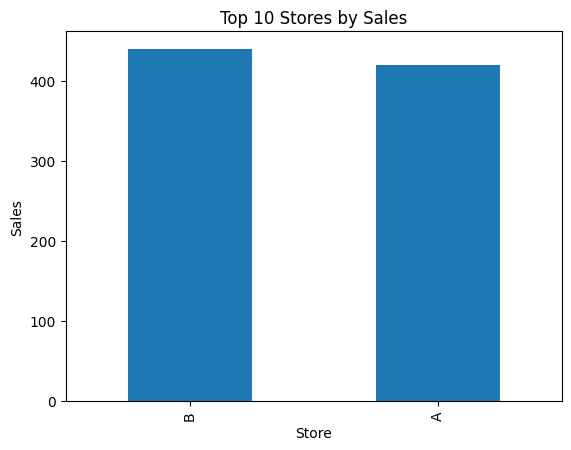

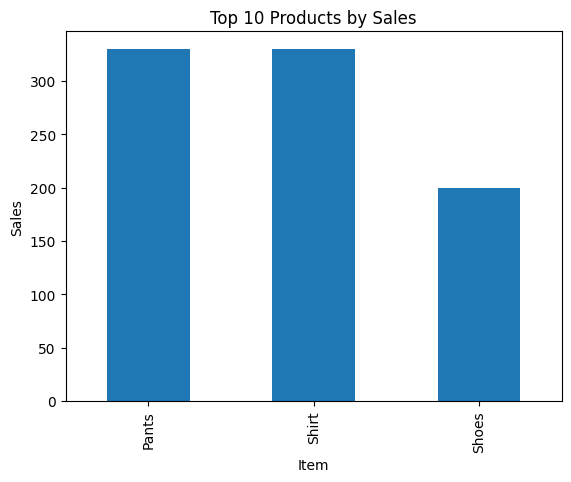

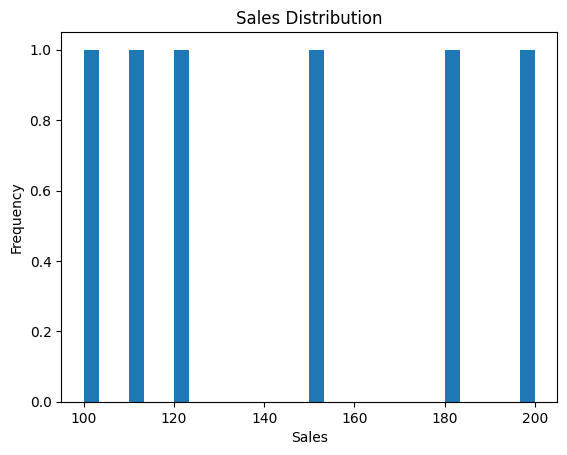

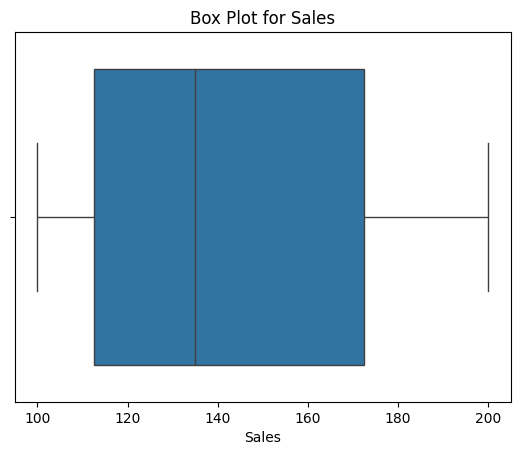

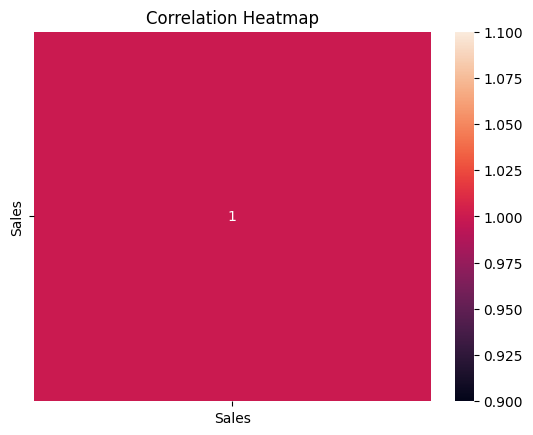


Top Store:
Store
B    440
Name: Sales, dtype: int64

Top Product:
Item
Pants    330
Name: Sales, dtype: int64


In [3]:
# -------------------------------------------
# Sales Forecasting Analysis System (EDA)
# -------------------------------------------

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------
# 2. Load Dataset
# -------------------------------------------
df = df_dummy

# Display first 5 rows
print("Dataset Preview:")
print(df.head())

# -------------------------------------------
# 3. Data Preprocessing
# -------------------------------------------

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# -------------------------------------------
# 4. Descriptive Statistics
# -------------------------------------------

print("\nDescriptive Statistics:")
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
print("Maximum Sales:", df['Sales'].max())
print("Minimum Sales:", df['Sales'].min())

# -------------------------------------------
# 5. Sales Trend Analysis
# -------------------------------------------

# Group by Date
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure()
plt.plot(daily_sales)
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# -------------------------------------------
# 6. Monthly Sales Analysis
# -------------------------------------------

df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# -------------------------------------------
# 7. Store Analysis
# -------------------------------------------

store_sales = df.groupby('Store')['Sales'].sum().sort_values(ascending=False)

plt.figure()
store_sales.head(10).plot(kind='bar')
plt.title("Top 10 Stores by Sales")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()

# -------------------------------------------
# 8. Product (Item) Analysis
# -------------------------------------------

item_sales = df.groupby('Item')['Sales'].sum().sort_values(ascending=False)

plt.figure()
item_sales.head(10).plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Item")
plt.ylabel("Sales")
plt.show()

# -------------------------------------------
# 9. Sales Distribution
# -------------------------------------------

plt.figure()
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# -------------------------------------------
# 10. Box Plot (Outlier Detection)
# -------------------------------------------

plt.figure()
sns.boxplot(x=df['Sales'])
plt.title("Box Plot for Sales")
plt.show()

# -------------------------------------------
# 11. Correlation Heatmap
# -------------------------------------------

# Select numeric columns
corr = df[['Sales']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------------------
# 12. Region Analysis (Optional)
# -------------------------------------------

if 'Region' in df.columns:
    region_sales = df.groupby('Region')['Sales'].sum()

    plt.figure()
    region_sales.plot(kind='bar')
    plt.title("Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Sales")
    plt.show()

# -------------------------------------------
# 13. Insights
# -------------------------------------------

print("\nTop Store:")
print(store_sales.head(1))

print("\nTop Product:")
print(item_sales.head(1))